In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("..")) 
from Datasets_n_simulator.simulator import simulate

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

In [100]:
infected_df = pd.read_csv("../Datasets_n_simulator/infected_timeseries.csv")
rewiring_df = pd.read_csv("../Datasets_n_simulator/rewiring_timeseries.csv")
degree_df = pd.read_csv("../Datasets_n_simulator/final_degree_histograms.csv")


In [101]:
infected_df = infected_df[infected_df["replicate_id"] == 0]
rewiring_df = rewiring_df[rewiring_df["replicate_id"] == 0]
degree_df = degree_df[degree_df["replicate_id"] == 0]
obs_infected = infected_df["infected_fraction"].values
obs_rewiring = rewiring_df["rewire_count"].values
obs_degree = degree_df["count"].values

In [102]:
def sample_prior(rng):
    beta = rng.uniform(0.05, 0.5)
    gamma = rng.uniform(0.02, 0.2)
    rho = rng.uniform(0.0, 0.8)
    return beta, gamma, rho

In [103]:
def compute_distances(summaries, s_obs):
    std = np.std(summaries, axis=0) + 1e-8
    dist = np.linalg.norm((summaries - s_obs) / std, axis=1)
    return dist

In [104]:
def rejection_abc_quantile(n_samples, s_obs, rng, compute_summary_func):
    thetas = []
    summaries = []

    for _ in range(n_samples):
        theta = sample_prior(rng)
        infected, rewiring, degree = simulate(*theta, rng=rng)

        s_sim = compute_summary_func(infected, rewiring, degree)

        thetas.append(theta)
        summaries.append(s_sim)

    thetas = np.array(thetas)           # shape (n, 3)
    summaries = np.array(summaries)     # shape (n, k)

    return thetas, summaries

In [105]:
def select_accepted(thetas, distances, quantile=0.05):
    epsilon = np.quantile(distances, quantile)

    indices = np.where(distances <= epsilon)[0]

    accepted_thetas = thetas[indices]

    return accepted_thetas, epsilon

In [106]:
rng = np.random.default_rng(42)
theta = sample_prior(rng)

In [107]:
def simulate_replicates(theta, compute_summary_func, R=40, rng=None):
    summaries = []
    for _ in range(R):
        infected, rewiring, degree = simulate(*theta, rng=rng)
        summaries.append(compute_summary_func(infected, rewiring, degree))
    return np.mean(summaries, axis=0)

In [108]:
# histogram plots of beta, rho, gamma
def plot_marginals(samples):
    beta = samples[:, 0]
    gamma = samples[:, 1]
    rho = samples[:, 2]

    # Means
    mean_beta = np.mean(beta)
    mean_gamma = np.mean(gamma)
    mean_rho = np.mean(rho)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot histograms and add mean lines
    axes[0].hist(beta, bins=30, color='skyblue', edgecolor='black')
    axes[0].axvline(mean_beta, color='red', linestyle='dashed', linewidth=2)
    axes[0].set_title(f"Posterior of β\nMean = {mean_beta:.2f}")

    axes[1].hist(gamma, bins=30, color='skyblue', edgecolor='black')
    axes[1].axvline(mean_gamma, color='red', linestyle='dashed', linewidth=2)
    axes[1].set_title(f"Posterior of γ\nMean = {mean_gamma:.2f}")

    axes[2].hist(rho, bins=30, color='skyblue', edgecolor='black')
    axes[2].axvline(mean_rho, color='red', linestyle='dashed', linewidth=2)
    axes[2].set_title(f"Posterior of ρ\nMean = {mean_rho:.2f}")

    plt.tight_layout()
    plt.show()

In [109]:
# pairwise scatter plot
def plot_pairwise(samples):
    beta = samples[:, 0]
    gamma = samples[:, 1]
    rho = samples[:, 2]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(beta, gamma, alpha=0.5)
    axes[0].set_xlabel("β")
    axes[0].set_ylabel("γ")
    axes[0].set_title("β vs γ")

    axes[1].scatter(beta, rho, alpha=0.5)
    axes[1].set_xlabel("β")
    axes[1].set_ylabel("ρ")
    axes[1].set_title("β vs ρ")

    axes[2].scatter(gamma, rho, alpha=0.5)
    axes[2].set_xlabel("γ")
    axes[2].set_ylabel("ρ")
    axes[2].set_title("γ vs ρ")

    plt.tight_layout()
    plt.show()

In [110]:
#acceptance rate
def plot_acceptance(epsilons, rates):
    plt.plot(epsilons, rates, marker='o')
    plt.xlabel("ε (tolerance)")
    plt.ylabel("Acceptance Rate")
    plt.title("Acceptance Rate vs Tolerance")
    plt.show()

In [154]:
#summary stats: 9
def compute_9_summary(infected, rewiring, degree):

    # Infection summaries
    peak_infection = np.max(infected)
    time_to_peak = np.argmax(infected)
    final_size = infected[-1]
    auc = np.sum(infected)  # discrete AUC

    # Recovery summary
    auc_to_peak_ratio = auc / peak_infection if peak_infection > 0 else 0

    # Rewiring summaries
    total_rewiring = np.sum(rewiring)
    peak_rewiring = np.max(rewiring)

    # Degree summaries
    degrees = np.arange(len(degree))
    total_nodes = np.sum(degree)

    mean_degree = np.sum(degrees * degree) / total_nodes
    var_degree = np.sum(((degrees - mean_degree) ** 2) * degree) / total_nodes

    return np.array([
        peak_infection,
        time_to_peak,
        final_size,
        auc,
        total_rewiring,
        peak_rewiring,
        mean_degree,
        var_degree,
        auc_to_peak_ratio
    ])

In [112]:
s_obs = compute_9_summary(obs_infected, obs_rewiring, obs_degree)
s_obs

array([5.40000000e-01, 9.00000000e+00, 0.00000000e+00, 9.90500000e+00,
       5.82000000e+02, 9.70000000e+01, 9.83000000e+00, 1.03411000e+01,
       1.83425926e+01])

In [113]:
s_sim = simulate_replicates(theta,compute_9_summary, R=40, rng=rng)

In [114]:
thetas, summaries = rejection_abc_quantile(
    n_samples=20000,
    s_obs=s_obs,
    rng=rng,
    compute_summary_func = compute_9_summary
)

In [116]:
dists = compute_distances(summaries, s_obs)
samples, epsilon = select_accepted(
    thetas,
    dists,
    quantile=0.05
)

print("Accepted samples:", samples.shape)
print("Epsilon used:", epsilon)

Accepted samples: (1000, 3)
Epsilon used: 1.4514657233441632


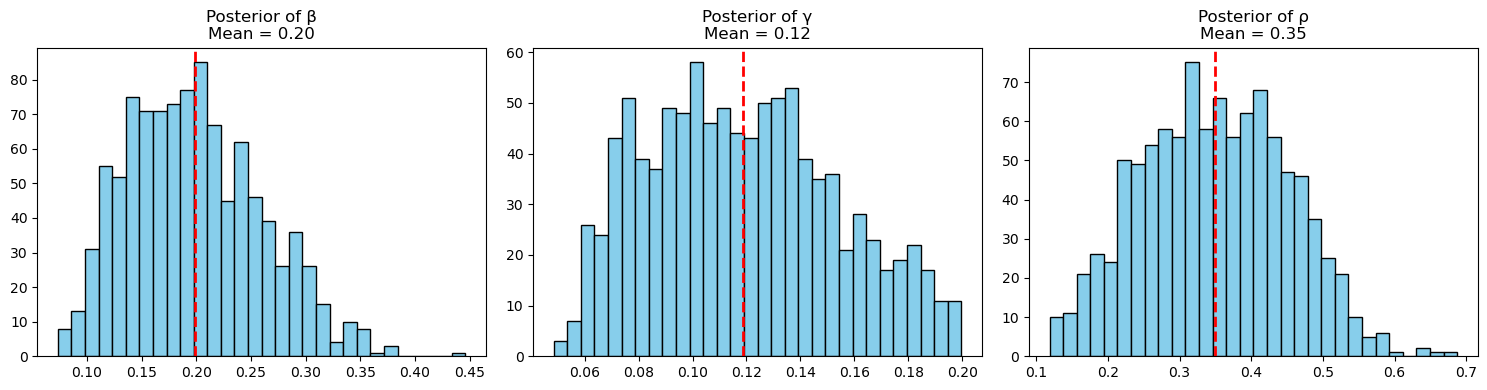

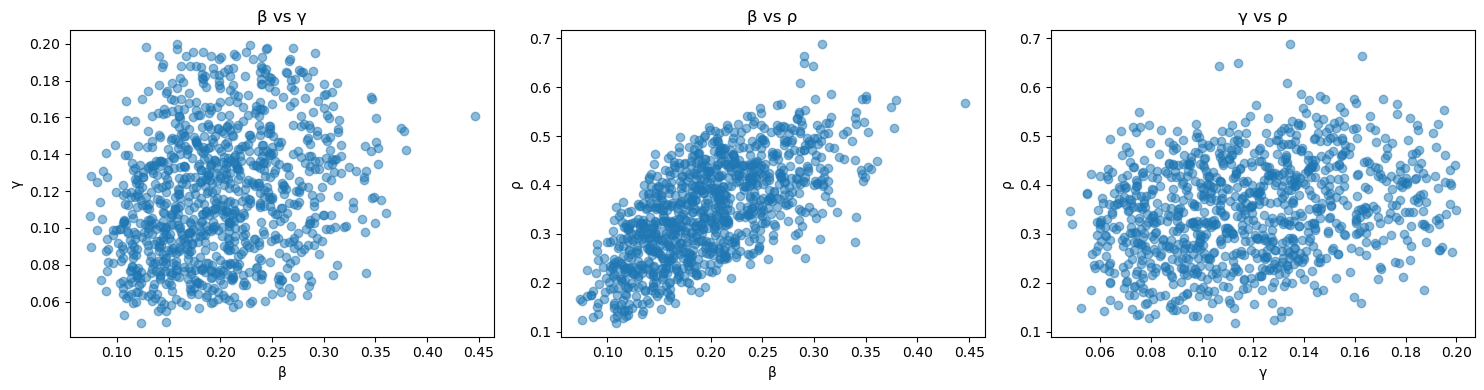

In [245]:
plot_marginals(samples)
plot_pairwise(samples)

In [118]:
# quantile-based epsilons
epsilons = np.quantile(dists, np.linspace(0.001, 0.1, 20))

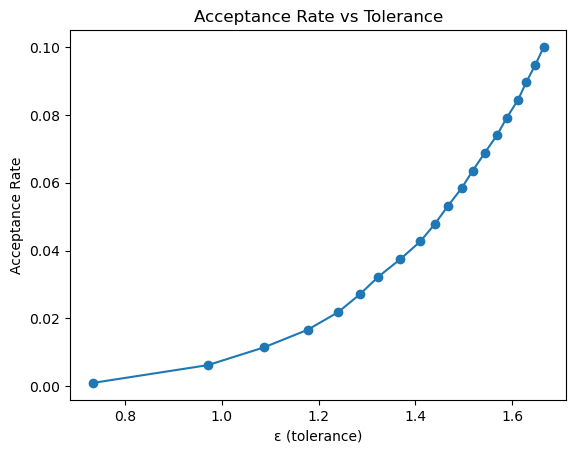

In [119]:
rates = []

for eps in epsilons:
    rate = np.mean(dists <= eps)
    rates.append(rate)

plot_acceptance(epsilons, rates)

In [120]:
#summary stats: 5
def compute_5_summary(infected, rewiring, degree):

    # Infection summaries
    peak_infection = np.max(infected)
    time_to_peak = np.argmax(infected)
    final_size = infected[-1]
    auc = np.sum(infected)  # discrete AUC

    # Recovery summary
    auc_to_peak_ratio = auc / peak_infection if peak_infection > 0 else 0
    decay_rate = np.polyfit(
        range(time_to_peak, len(infected)),
        np.log(infected[time_to_peak:] + 1e-8),
        1
    )[0]

    # Rewiring summaries
    total_rewiring = np.sum(rewiring)
    peak_rewiring = np.max(rewiring)

    # Degree summaries
    degrees = np.arange(len(degree))
    total_nodes = np.sum(degree)

    mean_degree = np.sum(degrees * degree) / total_nodes
    var_degree = np.sum(((degrees - mean_degree) ** 2) * degree) / total_nodes

    return np.array([
        peak_infection,
        time_to_peak,
        final_size,
        auc,
        total_rewiring
    ])

In [121]:
s5_obs = compute_5_summary(obs_infected, obs_rewiring, obs_degree)
s5_obs

array([5.400e-01, 9.000e+00, 0.000e+00, 9.905e+00, 5.820e+02])

In [122]:
thetas5, summaries5 = rejection_abc_quantile(
    n_samples=20000,
    s_obs=s5_obs,
    rng=rng,
    compute_summary_func= compute_5_summary
)

In [123]:
dists5 = compute_distances(summaries5, s5_obs)
samples5, epsilon5 = select_accepted(
    thetas5,
    dists5,
    quantile=0.05
)

print("Accepted samples:", samples5.shape)
print("Epsilon used:", epsilon5)

Accepted samples: (1000, 3)
Epsilon used: 0.8062607141004964


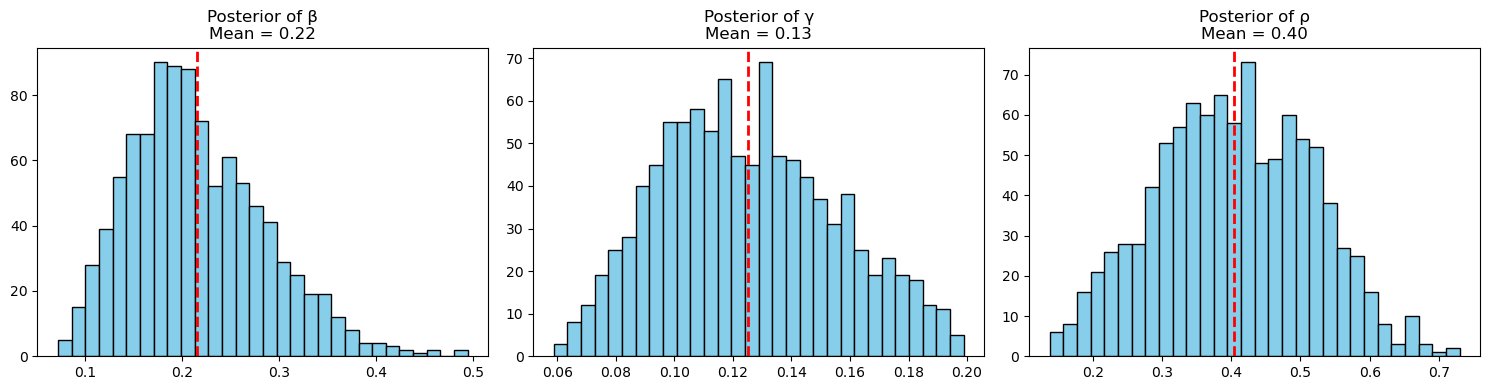

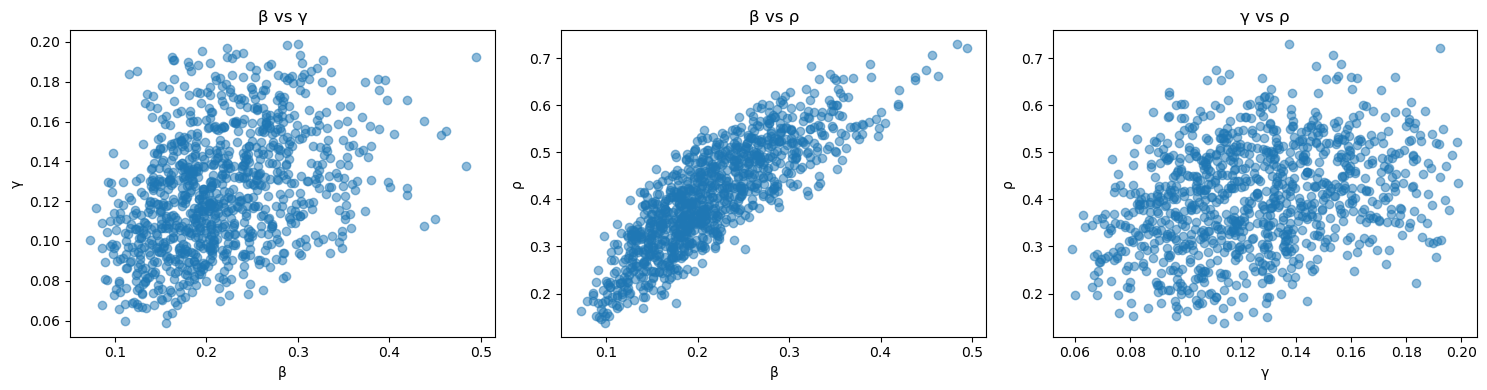

In [244]:
plot_marginals(samples5)
plot_pairwise(samples5)


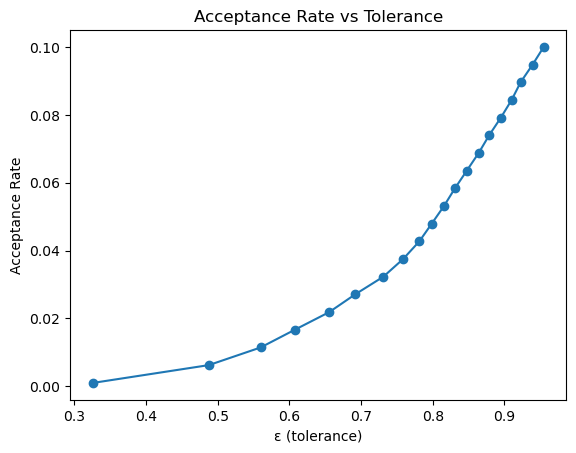

In [125]:
epsilons = np.quantile(dists5, np.linspace(0.001, 0.1, 20))
rates = []

for eps in epsilons:
    rate = np.mean(dists5 <= eps)
    rates.append(rate)

plot_acceptance(epsilons, rates)

In [ ]:
#summary stats: 6
def compute_6_summary(infected, rewiring, degree):

    # Infection summaries
    peak_infection = np.max(infected)
    time_to_peak = np.argmax(infected)
    final_size = infected[-1]
    auc = np.sum(infected)  # discrete AUC

    # Recovery summary
    auc_to_peak_ratio = auc / peak_infection if peak_infection > 0 else 0
    decay_rate = np.polyfit(
        range(time_to_peak, len(infected)),
        np.log(infected[time_to_peak:] + 1e-8),
        1
    )[0]

    # Rewiring summaries
    total_rewiring = np.sum(rewiring)
    peak_rewiring = np.max(rewiring)
    #rewiring_timing = np.argmax(rewiring)

    # Degree summaries
    degrees = np.arange(len(degree))
    total_nodes = np.sum(degree)

    mean_degree = np.sum(degrees * degree) / total_nodes
    var_degree = np.sum(((degrees - mean_degree) ** 2) * degree) / total_nodes

    return np.array([
        peak_infection,
        time_to_peak,
        final_size,
        auc,
        total_rewiring,
        peak_rewiring
    ])

In [127]:
s6_obs = compute_6_summary(obs_infected, obs_rewiring, obs_degree)
s6_obs

array([5.400e-01, 9.000e+00, 0.000e+00, 9.905e+00, 5.820e+02, 7.000e+00])

In [128]:
thetas6, summaries6 = rejection_abc_quantile(
    n_samples=20000,
    s_obs=s6_obs,
    rng=rng,
    compute_summary_func= compute_6_summary
)

In [129]:
dists6 = compute_distances(summaries6, s6_obs)
samples6, epsilon6 = select_accepted(
    thetas6,
    dists6,
    quantile=0.05
)

print("Accepted samples:", samples6.shape)
print("Epsilon used:", epsilon6)

Accepted samples: (1000, 3)
Epsilon used: 1.0203204609756622


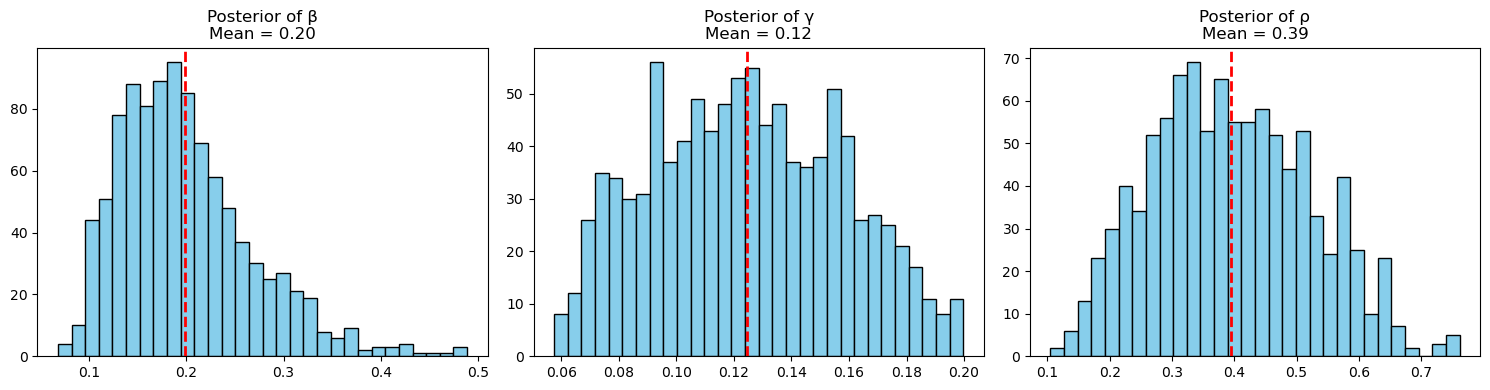

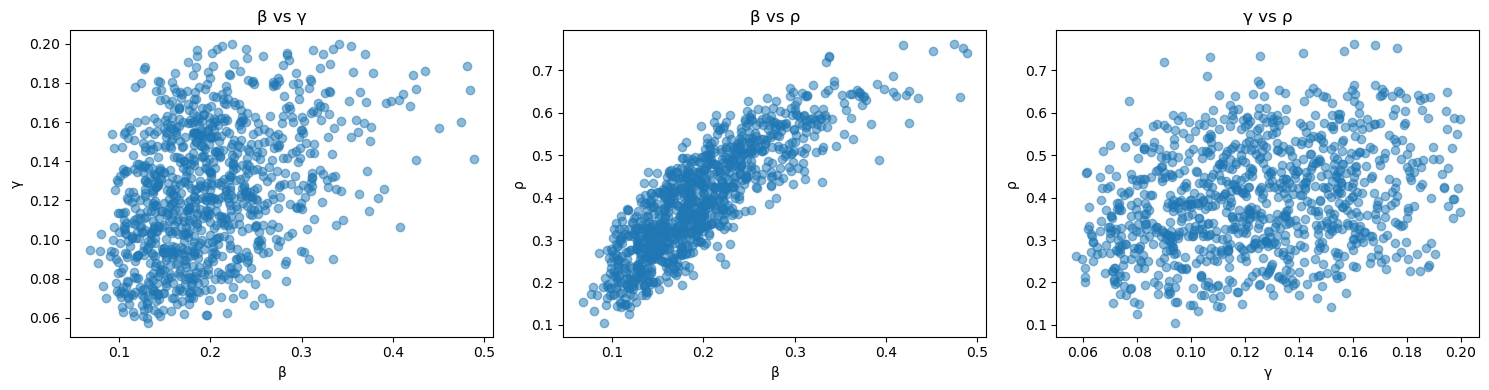

In [243]:
plot_marginals(samples6)
plot_pairwise(samples6)

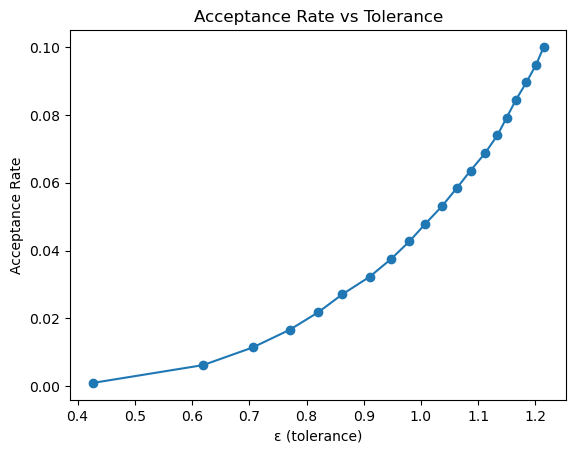

In [131]:
epsilons = np.quantile(dists6, np.linspace(0.001, 0.1, 20))
rates = []

for eps in epsilons:
    rate = np.mean(dists6 <= eps)
    rates.append(rate)

plot_acceptance(epsilons, rates)

In [132]:
#summary stats: 8
def compute_8_summary(infected, rewiring, degree):

    # Infection summaries
    peak_infection = np.max(infected)
    time_to_peak = np.argmax(infected)
    final_size = infected[-1]
    auc = np.sum(infected)  # discrete AUC

    # Recovery summary
    auc_to_peak_ratio = auc / peak_infection if peak_infection > 0 else 0
    decay_rate = np.polyfit(
        range(time_to_peak, len(infected)),
        np.log(infected[time_to_peak:] + 1e-8),
        1
    )[0]

    # Rewiring summaries
    total_rewiring = np.sum(rewiring)
    peak_rewiring = np.max(rewiring)

    # Degree summaries
    degrees = np.arange(len(degree))
    total_nodes = np.sum(degree)

    mean_degree = np.sum(degrees * degree) / total_nodes
    var_degree = np.sum(((degrees - mean_degree) ** 2) * degree) / total_nodes

    return np.array([
        peak_infection,
        time_to_peak,
        final_size,
        auc,
        total_rewiring,
        peak_rewiring,
        mean_degree,
        var_degree
        #auc_to_peak_ratio,
    ])

In [133]:
s8_obs = compute_8_summary(obs_infected, obs_rewiring, obs_degree)
s8_obs

array([5.40000e-01, 9.00000e+00, 0.00000e+00, 9.90500e+00, 5.82000e+02,
       9.70000e+01, 9.83000e+00, 1.03411e+01])

In [134]:
thetas8, summaries8 = rejection_abc_quantile(
    n_samples=20000,
    s_obs=s8_obs,
    rng=rng,
    compute_summary_func=compute_8_summary
)

In [135]:
dists8 = compute_distances(summaries8, s8_obs)
samples8, epsilon8 = select_accepted(
    thetas8,
    dists8,
    quantile=0.05
)

print("Accepted samples:", samples8.shape)
print("Epsilon used:", epsilon)

Accepted samples: (1000, 3)
Epsilon used: 1.4514657233441632


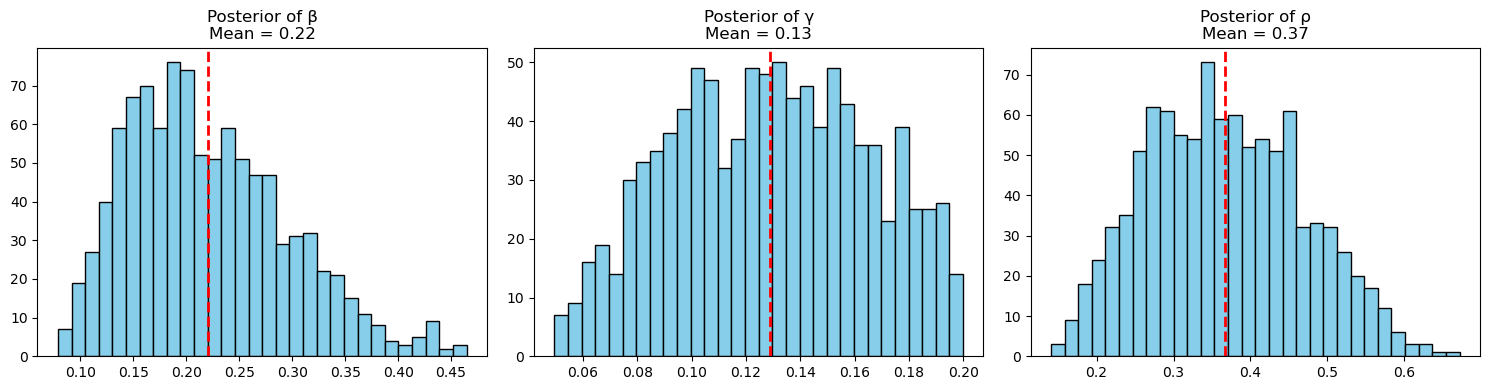

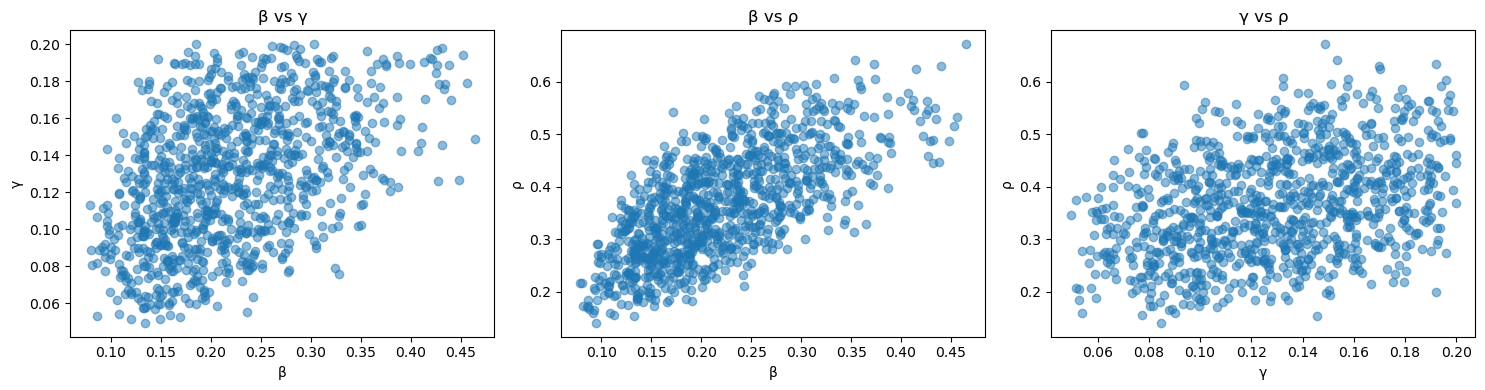

In [242]:
plot_marginals(samples8)
plot_pairwise(samples8)

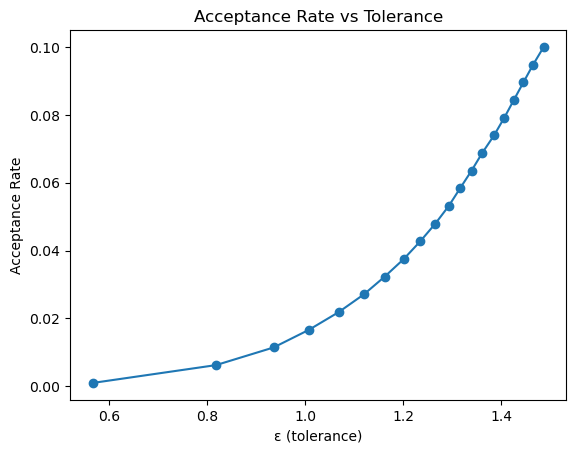

In [137]:
epsilons = np.quantile(dists8, np.linspace(0.001, 0.1, 20))
rates = []

for eps in epsilons:
    rate = np.mean(dists8 <= eps)
    rates.append(rate)

plot_acceptance(epsilons, rates)

In [138]:
#summary stats: w/o auc_to_peak_ratio
def compute_l_summary(infected, rewiring, degree):

    # Infection summaries
    peak_infection = np.max(infected)
    time_to_peak = np.argmax(infected)
    final_size = infected[-1]
    auc = np.sum(infected)  # discrete AUC

    # Recovery summary
    auc_to_peak_ratio = auc / peak_infection if peak_infection > 0 else 0
    decay_rate = np.polyfit(
        range(time_to_peak, len(infected)),
        np.log(infected[time_to_peak:] + 1e-8),
        1
    )[0]

    # Rewiring summaries
    total_rewiring = np.sum(rewiring)
    peak_rewiring = np.max(rewiring)
    rewiring_timing = np.argmax(rewiring)

    # Degree summaries
    degrees = np.arange(len(degree))
    total_nodes = np.sum(degree)

    mean_degree = np.sum(degrees * degree) / total_nodes
    var_degree = np.sum(((degrees - mean_degree) ** 2) * degree) / total_nodes

    return np.array([
        peak_infection,
        time_to_peak,
        final_size,
        auc,
        total_rewiring,
        peak_rewiring,
        mean_degree,
        var_degree,
        rewiring_timing
        #auc_to_peak_ratio,
    ])

In [139]:
sl_obs = compute_l_summary(obs_infected, obs_rewiring, obs_degree)
sl_obs

array([5.40000e-01, 9.00000e+00, 0.00000e+00, 9.90500e+00, 5.82000e+02,
       9.70000e+01, 9.83000e+00, 1.03411e+01, 7.00000e+00])

In [140]:
thetasl, summariesl = rejection_abc_quantile(
    n_samples=20000,
    s_obs=sl_obs,
    rng=rng,
    compute_summary_func=compute_l_summary
)

In [141]:
distsl = compute_distances(summariesl, sl_obs)
samplesl, epsilonl = select_accepted(
    thetasl,
    distsl,
    quantile=0.05
)

print("Accepted samples:", samplesl.shape)
print("Epsilon used:", epsilonl)

Accepted samples: (1000, 3)
Epsilon used: 1.4639070931568015


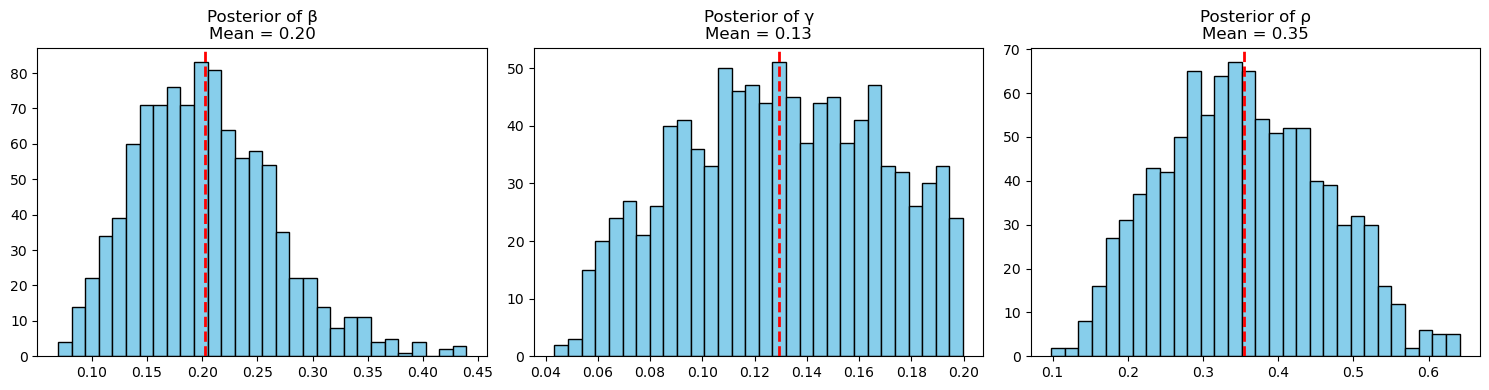

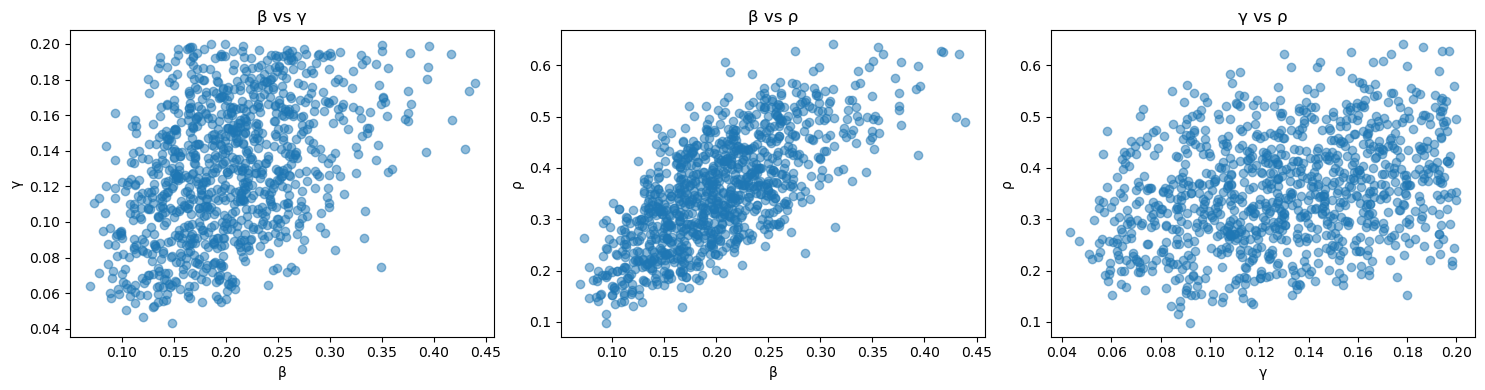

In [241]:
plot_marginals(samplesl)
plot_pairwise(samplesl)

In [143]:
epsilons = np.quantile(distsl, np.linspace(0.001, 0.1, 20))
rates = []

for eps in epsilons:
    rate = np.mean(distsl <= eps)
    rates.append(rate)

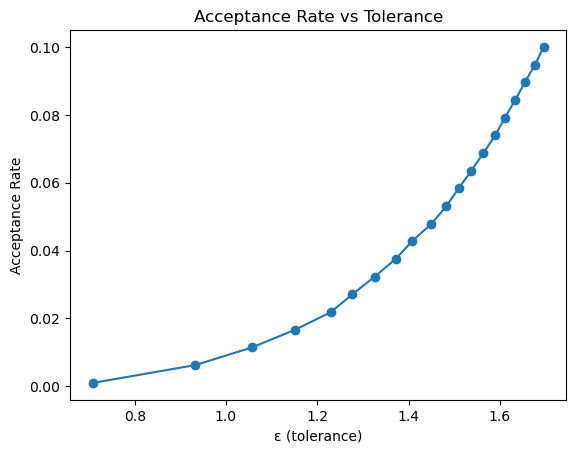

In [144]:
plot_acceptance(epsilons, rates)

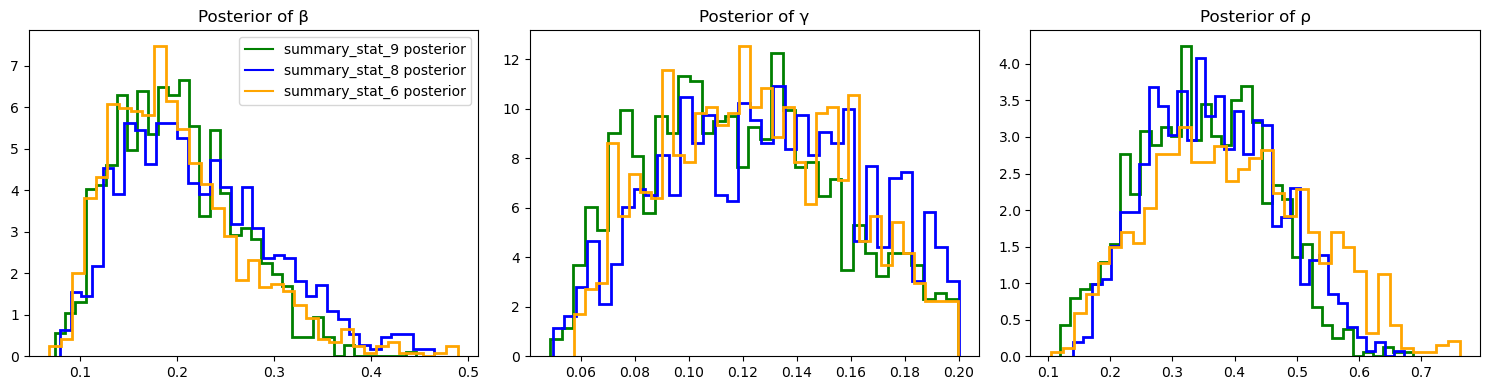

In [287]:
def plot_all_marginals(samples, samples2, samples3):
    beta = samples[:, 0]
    gamma = samples[:, 1]
    rho = samples[:, 2]

    beta2 = samples2[:, 0]
    gamma2 = samples2[:, 1]
    rho2 = samples2[:, 2]

    beta3 = samples3[:, 0]
    gamma3 = samples3[:, 1]
    rho3 = samples3[:, 2]

    # Means
    mean_beta = np.mean(beta)
    mean_gamma = np.mean(gamma)
    mean_rho = np.mean(rho)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot histograms and add mean lines
    axes[0].hist(beta, bins=35, density=True, histtype='step', color='green', linewidth=2)
    axes[0].hist(beta2, bins=35, density=True, histtype='step', color='blue', linewidth=2)
    axes[0].hist(beta3, bins=35, density=True, histtype='step', color='orange', linewidth=2)        
    #axes[0].axvline(mean_beta, color='red', linestyle='dashed', linewidth=2)
    axes[0].set_title(f"Posterior of β")
    axes[0].plot([], [], color='green', label='summary_stat_9 posterior')
    axes[0].plot([], [], color='blue', label='summary_stat_8 posterior')
    axes[0].plot([], [], color='orange', label='summary_stat_6 posterior')
    axes[0].legend()


    axes[1].hist(gamma, bins=35, density=True, histtype='step', color='green', linewidth=2)  
    axes[1].hist(gamma2, bins=35, density=True, histtype='step', color='blue', linewidth=2)
    axes[1].hist(gamma3, bins=35, density=True, histtype='step', color='orange', linewidth=2)      
    #axes[1].axvline(mean_gamma, color='red', linestyle='dashed', linewidth=2)
    axes[1].set_title(f"Posterior of γ")

    axes[2].hist(rho, bins=35, density=True, histtype='step', color='green', linewidth=2)      
    axes[2].hist(rho2, bins=35, density=True, histtype='step', color='blue', linewidth=2)      
    axes[2].hist(rho3, bins=35, density=True, histtype='step', color='orange', linewidth=2)      
    
    #axes[2].axvline(mean_rho, color='red', linestyle='dashed', linewidth=2)
    axes[2].set_title(f"Posterior of ρ")

    plt.tight_layout()
    plt.show()

plot_all_marginals(samples, samples8, samples6)

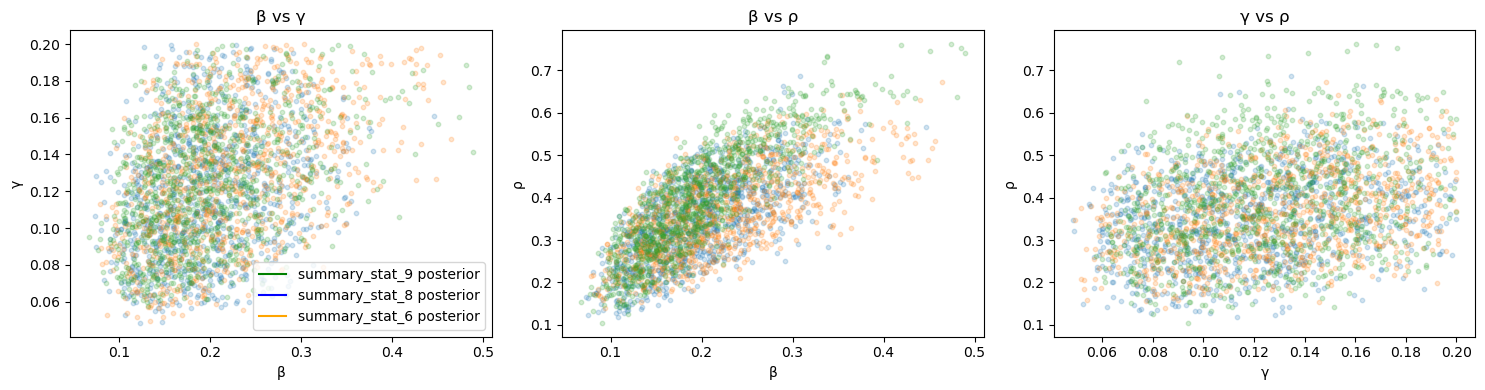

In [292]:
# pairwise scatter plot
def plot_all_pairwise(samples, samples2, samples3):
    beta = samples[:, 0]
    gamma = samples[:, 1]
    rho = samples[:, 2]
    
    beta2 = samples2[:, 0]
    gamma2 = samples2[:, 1]
    rho2 = samples2[:, 2]

    beta3 = samples3[:, 0]
    gamma3 = samples3[:, 1]
    rho3 = samples3[:, 2]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(beta, gamma, s=10, alpha=0.2)
    axes[0].scatter(beta2, gamma2, s=10, alpha=0.2)
    axes[0].scatter(beta3, gamma3, s=10, alpha=0.2)
    axes[0].set_xlabel("β")
    axes[0].set_ylabel("γ")
    axes[0].set_title("β vs γ")
    axes[0].plot([], [], color='green', label='summary_stat_9 posterior')
    axes[0].plot([], [], color='blue', label='summary_stat_8 posterior')
    axes[0].plot([], [], color='orange', label='summary_stat_6 posterior')
    axes[0].legend()

    axes[1].scatter(beta, rho, s=10, alpha=0.2)
    axes[1].scatter(beta2, rho2, s=10, alpha=0.2)
    axes[1].scatter(beta3, rho3, s=10, alpha=0.2)
    axes[1].set_xlabel("β")
    axes[1].set_ylabel("ρ")
    axes[1].set_title("β vs ρ")

    axes[2].scatter(gamma, rho, s=10, alpha=0.2)
    axes[2].scatter(gamma2, rho2, s=10, alpha=0.2)
    axes[2].scatter(gamma3, rho3, s=10, alpha=0.2)
    axes[2].set_xlabel("γ")
    axes[2].set_ylabel("ρ")
    axes[2].set_title("γ vs ρ")

    plt.tight_layout()
    plt.show()

plot_all_pairwise(samples, samples8, samples6)

# Evaluation

In [ ]:
# posterior predictive check
def post_pred(accepted_thetas, obs_infected, obs_rewiring, obs_degree):

    posterior_samples = accepted_thetas  # from ABC
    idx = rng.choice(len(posterior_samples), size=100, replace=False)
    theta_draws = posterior_samples[idx]

    simulated_datasets = []
    for theta in theta_draws:
        simulated_datasets.append(simulate(*theta, rng=rng))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Infection time series
    for infected, _, _ in simulated_datasets:
        axes[0].plot(infected, color='gray', alpha=0.2)
    axes[0].plot(obs_infected, color='red', linewidth=2)
    axes[0].set_title("Posterior predictive: infected fraction")

    # Rewiring time series
    for _, rewiring, _ in simulated_datasets:
        axes[1].plot(rewiring, color='gray', alpha=0.2)
    axes[1].plot(obs_rewiring, color='red', linewidth=2)
    axes[1].set_title("Posterior predictive: rewiring")

    # Degree distribution
    for _, _, degree in simulated_datasets:
        axes[2].plot(degree, color='gray', alpha=0.2)
    axes[2].plot(obs_degree, color='red', linewidth=2)
    axes[2].set_title("Posterior predictive: degree distribution")

    plt.tight_layout()
    plt.show()

    # compute MSE
    mses_infected = []
    mses_rewiring = []
    mses_degree = []

    for infected, rewiring, degree in simulated_datasets:
        mses_infected.append(np.mean((infected - obs_infected)**2))
        mses_rewiring.append(np.mean((rewiring - obs_rewiring)**2))
        mses_degree.append(np.mean((degree - obs_degree)**2))

    print("Mean MSE infected:", np.mean(mses_infected))
    print("Mean MSE rewiring:", np.mean(mses_rewiring))
    print("Mean MSE degree:", np.mean(mses_degree))

    infected_sims = np.array([sim[0] for sim in simulated_datasets])
    mean_infected = infected_sims.mean(axis=0)
    mse_infected = np.mean((mean_infected - obs_infected)**2)
    print(f'MSE of mean for infected: {mse_infected}')

    rewire_sims = np.array([sim[1] for sim in simulated_datasets])
    mean_rewire = rewire_sims.mean(axis=0)
    mse_rewire = np.mean((mean_rewire - obs_rewiring)**2)
    print(f'MSE of mean for rewiring: {mse_rewire}')

    degree_sims = np.array([sim[2] for sim in simulated_datasets])
    mean_degree = degree_sims.mean(axis=0)
    mse_degree = np.mean((mean_degree - obs_degree)**2)
    print(f'MSE of mean for degree: {mse_degree}')

test_index = rng.choice(np.arange(31), size =8, replace = False )
obs_infected_test = obs_infected[test_index]
obs_rewiring_test = obs_rewiring[test_index]
obs_degree_test = obs_degree[test_index]


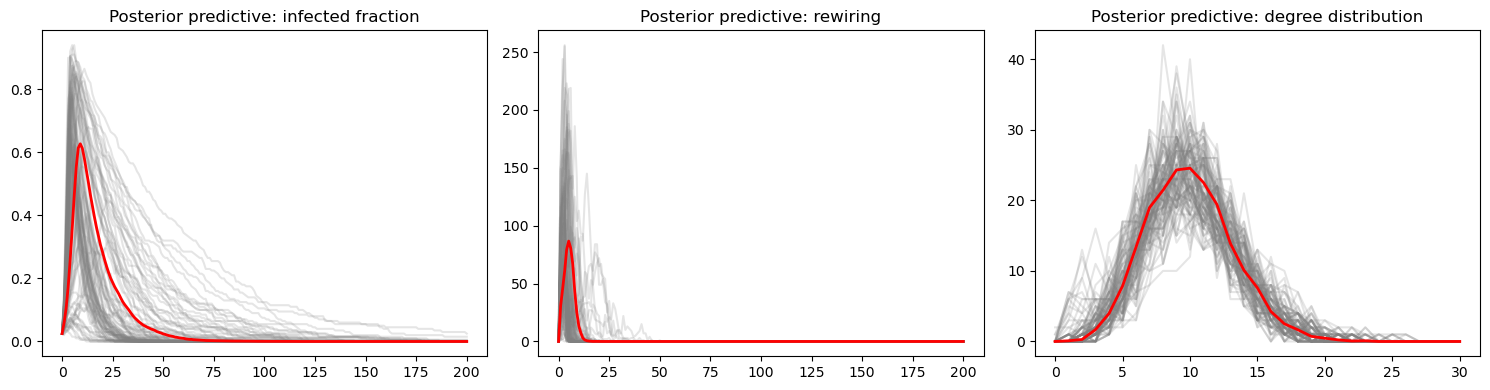

Mean MSE infected: 0.01094262839610541
Mean MSE rewiring: 158.66468400186568
Mean MSE degree: 8.041504536290324
MSE of posterior mean for infected: 0.0022606251125233214
MSE of posterior mean for rewiring: 51.84474818097015
MSE of posterior mean for degree: 0.343775504032258


In [265]:
# compare simulated datasets using posterior from summary stat 9 with actual dataset
post_pred(thetas, obs_infected, obs_rewiring, obs_degree)

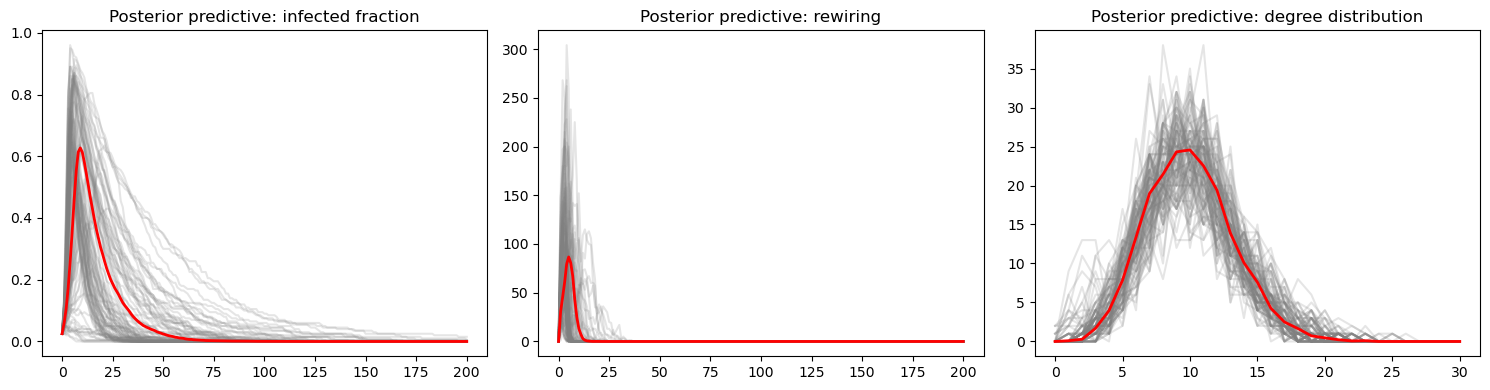

Mean MSE infected: 0.010162696570856656
Mean MSE rewiring: 168.01597753420396
Mean MSE degree: 7.634065020161291
MSE of posterior mean for infected: 0.0019535262972248135
MSE of posterior mean for rewiring: 49.90947753420399
MSE of posterior mean for degree: 0.262768245967742


In [260]:
# compare simulated datasets using posterior from summary stat 6 with actual dataset
post_pred(thetas6, obs_infected, obs_rewiring, obs_degree)

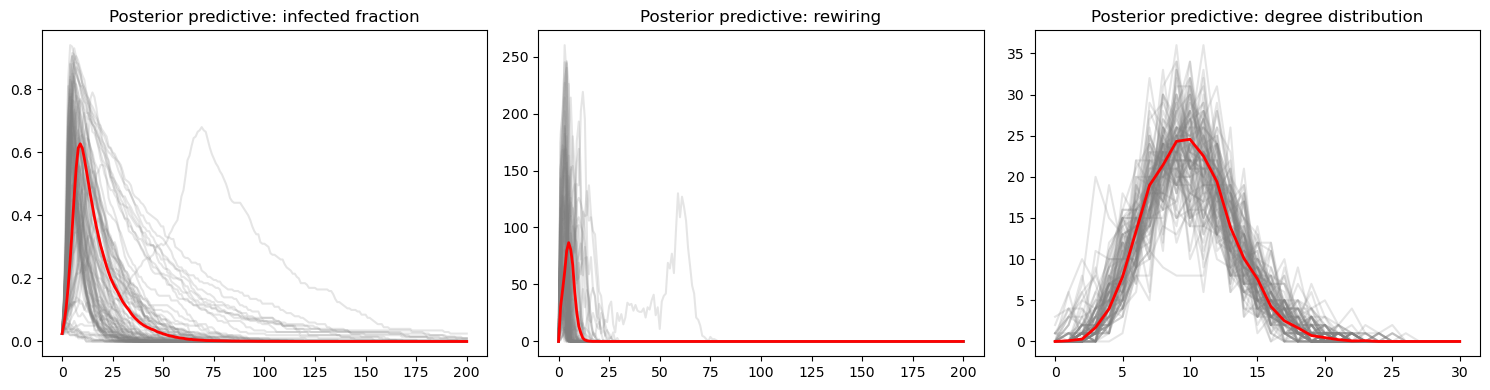

Mean MSE infected: 0.010373072970110387
Mean MSE rewiring: 195.9716149720149
Mean MSE degree: 8.40305695564516
MSE of posterior mean for infected: 0.002182523965135261
MSE of posterior mean for rewiring: 49.67293089241294
MSE of posterior mean for degree: 0.475934375


In [275]:
# compare simulated datasets using posterior from summary stat 8 with actual dataset
post_pred(thetas8, obs_infected, obs_rewiring, obs_degree)

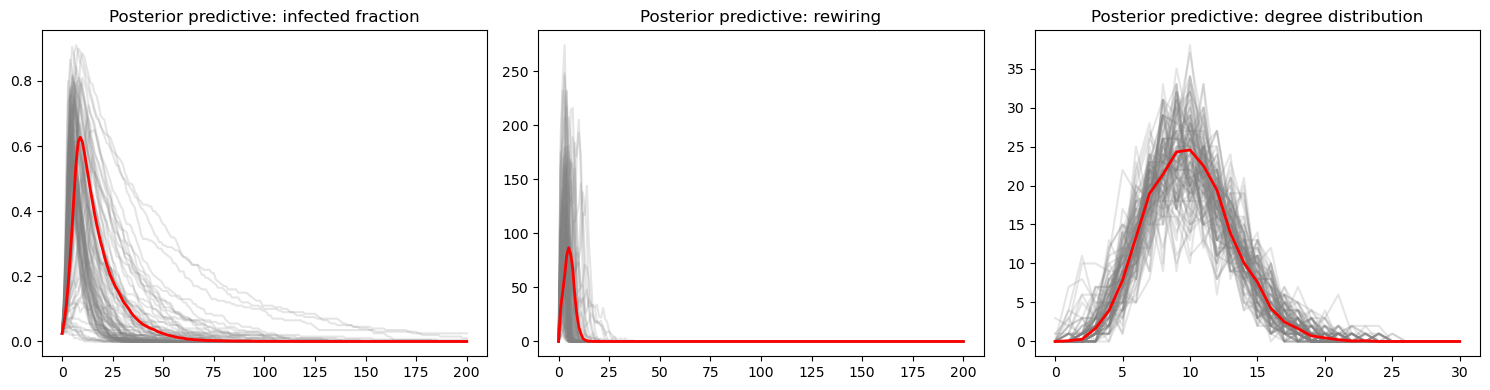

Mean MSE infected: 0.008873864481304415
Mean MSE rewiring: 167.62913362873135
Mean MSE degree: 7.991060987903228
MSE of posterior mean for infected: 0.0027340900534437184
MSE of posterior mean for rewiring: 41.06748238495025
MSE of posterior mean for degree: 0.4077771169354841


In [262]:
# compare simulated datasets using posterior from summary stat 5 with actual dataset
post_pred(thetas5, obs_infected, obs_rewiring, obs_degree)

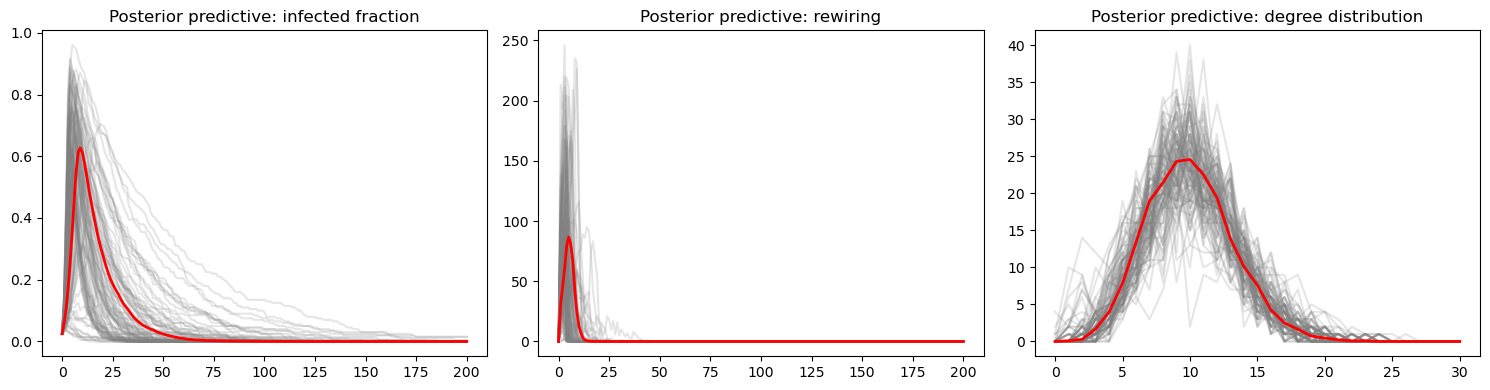

Mean MSE infected: 0.009307568150458644
Mean MSE rewiring: 150.70692591728854
Mean MSE degree: 8.630496471774192
MSE of posterior mean for infected: 0.0020032960360307837
MSE of posterior mean for rewiring: 46.65267765858209
MSE of posterior mean for degree: 0.34366421370967726


In [263]:
# compare simulated datasets using posterior from summary stat l with actual dataset
post_pred(thetasl, obs_infected, obs_rewiring, obs_degree)

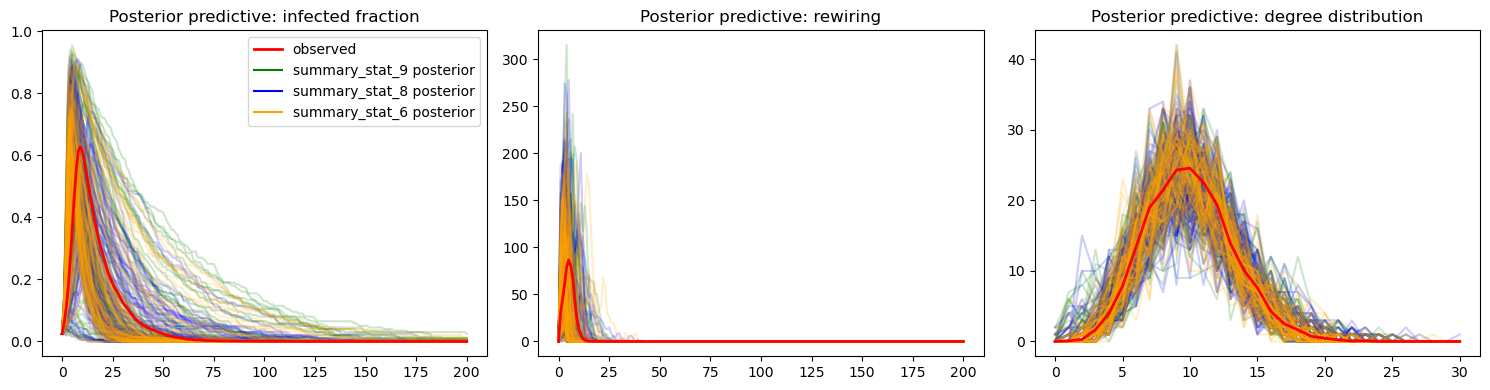

In [280]:
# posterior predictive check
def post_pred(accepted_thetas, accepted_thetas2, accepted_thetas3, obs_infected, obs_rewiring, obs_degree):

    posterior_samples = accepted_thetas  # from ABC
    idx = rng.choice(len(posterior_samples), size=100, replace=False)
    theta_draws = posterior_samples[idx]

    post_samp2 = accepted_thetas2
    post_samp3 = accepted_thetas3
    theta_draws2 = post_samp2[idx]
    theta_draws3 = post_samp3[idx]

    simulated_datasets = []
    sim_dataset2 = []
    sim_dataset3 = []
    for theta in theta_draws:
        simulated_datasets.append(simulate(*theta, rng=rng))

    for theta in theta_draws2:
        sim_dataset2.append(simulate(*theta, rng=rng))

    for theta in theta_draws3:
        sim_dataset3.append(simulate(*theta, rng=rng))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Infection time series
    for infected, _, _ in simulated_datasets:
        axes[0].plot(infected, color='green', alpha=0.2)

    for infected, _, _ in sim_dataset2:
        axes[0].plot(infected, color='blue', alpha=0.2)

    for infected, _, _ in sim_dataset3:
        axes[0].plot(infected, color='orange', alpha=0.2)

    axes[0].plot(obs_infected, color='red', linewidth=2, label='observed')
    axes[0].set_title("Posterior predictive: infected fraction")
    axes[0].plot([], [], color='green', label='summary_stat_9 posterior')
    axes[0].plot([], [], color='blue', label='summary_stat_8 posterior')
    axes[0].plot([], [], color='orange', label='summary_stat_6 posterior')
    axes[0].legend()


    # Rewiring time series
    for _, rewiring, _ in simulated_datasets:
        axes[1].plot(rewiring, color='green', alpha=0.2)

    for _, rewiring, _ in sim_dataset2:
        axes[1].plot(rewiring, color='blue', alpha=0.2)

    for _, rewiring, _ in sim_dataset3:
        axes[1].plot(rewiring, color='orange', alpha=0.2)

    axes[1].plot(obs_rewiring, color='red', linewidth=2)
    axes[1].set_title("Posterior predictive: rewiring")


    # Degree distribution
    for _, _, degree in simulated_datasets:
        axes[2].plot(degree, color='green', alpha=0.2)

    for _, _, degree in sim_dataset2:
        axes[2].plot(degree, color='blue', alpha=0.2)

    for _, _, degree in sim_dataset3:
        axes[2].plot(degree, color='orange', alpha=0.2)

    
    axes[2].plot(obs_degree, color='red', linewidth=2)
    axes[2].set_title("Posterior predictive: degree distribution")

    plt.tight_layout()
    plt.show()
post_pred(thetas, thetas8, thetas6, obs_infected, obs_rewiring, obs_degree)


In [252]:
# compare posterior means to true params
# a fake true parameter from prior: assume this is true parameter, how does summary statistics perform
theta_true = (0.25, 0.1, 0.3)  # 1 try from prior (beta, gamma, rho)
infected_obs_t, rewiring_obs_t, degree_obs_t = simulate(*theta_true, rng=rng)

#ABC pipeline
def abc_pipeline(compute_summary_func,infected_obs_t, rewiring_obs_t, degree_obs_t):
    # sample from prior
    s_obs = compute_summary_func(infected_obs_t, rewiring_obs_t, degree_obs_t)
    # simulate_replicates(theta)
    thetas, summaries = rejection_abc_quantile(
        n_samples=20000,
        s_obs=s_obs,
        rng=rng,
        compute_summary_func = compute_summary_func
    )
    # compute distance to s_obs
    dists = compute_distances(summaries, s_obs)
    samples, epsilon = select_accepted(
        thetas,
        dists,
        quantile=0.05
    )
    # calculate MSE
    mse = np.mean((samples - np.array(theta_true))**2, axis=0)
    print("MSE (beta, gamma, rho):", mse)  
    std = np.std(samples, axis=0)
    print("std (beta, gamma, rho):", std)  

    print(f'95% CI of Beta: {np.percentile(samples[:, 0], [2.5, 97.5])}')
    print(f'95% CI of Gamma: {np.percentile(samples[:, 1], [2.5, 97.5])}')
    print(f'95% CI of Rho: {np.percentile(samples[:, 2], [2.5, 97.5])}')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Beta
    axes[0].hist(samples[:, 0], bins=30, density=True)
    axes[0].axvline(theta_true[0], color='red')
    axes[0].set_title("Histogram of accepted Beta with 'True' beta")

    # Gamma
    axes[1].hist(samples[:, 1], bins=30, density=True)
    axes[1].axvline(theta_true[1], color='red')
    axes[1].set_title("Histogram of accepted Gamma with 'True' Gamma")

    # Rho
    axes[2].hist(samples[:, 2], bins=30, density=True)
    axes[2].axvline(theta_true[2], color='red')
    axes[2].set_title("Histogram of accepted rho with 'True' rho")

    plt.tight_layout()
    plt.show()

MSE (beta, gamma, rho): [0.01699917 0.00272245 0.06295342]
std (beta, gamma, rho): [0.12761415 0.05088133 0.23012633]
95% CI of Beta: [0.06232294 0.4877271 ]
95% CI of Gamma: [0.02666225 0.19544712]
95% CI of Rho: [0.01981872 0.78025689]


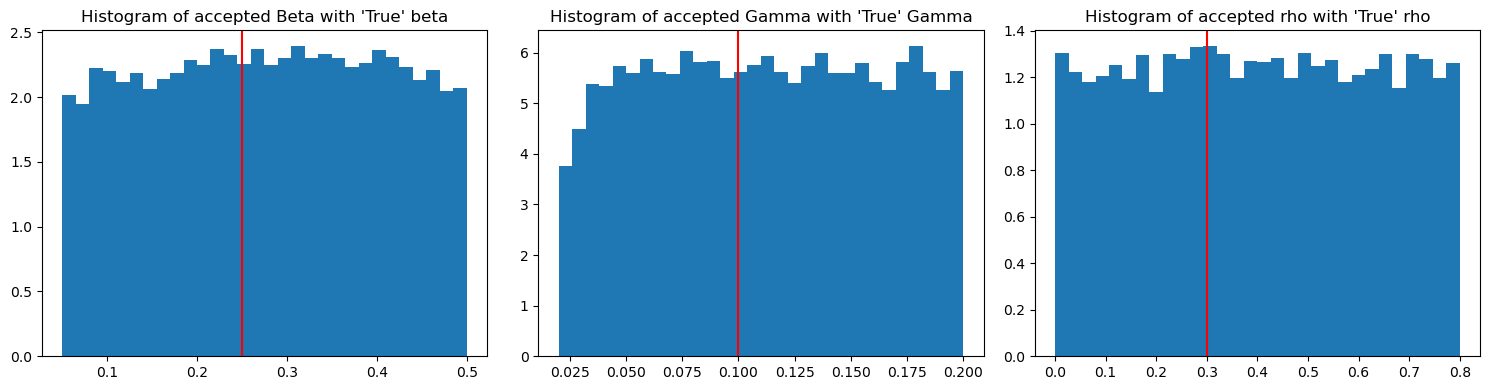

In [253]:
# evaluate 9 summary stats ABC performance on fake parameter
abc_pipeline(compute_9_summary,infected_obs_t, rewiring_obs_t, degree_obs_t)

MSE (beta, gamma, rho): [0.01068101 0.00059197 0.01235279]
std (beta, gamma, rho): [0.07979154 0.02204075 0.09278452]
95% CI of Beta: [0.18021687 0.47183439]
95% CI of Gamma: [0.07472903 0.15452264]
95% CI of Rho: [0.18723579 0.53268587]


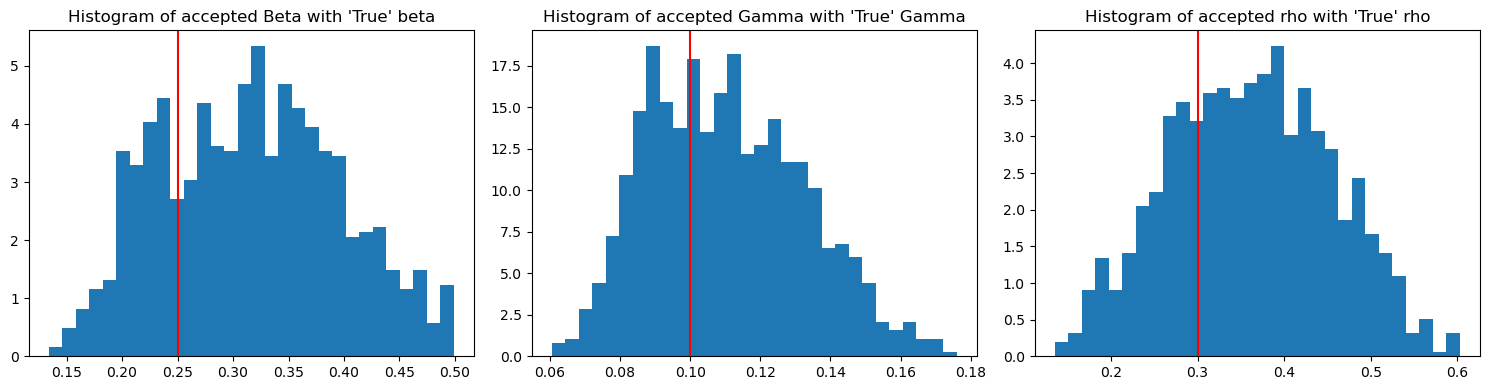

In [254]:
# evaluate 6 summary stats ABC performance on fake parameter
abc_pipeline(compute_6_summary,infected_obs_t, rewiring_obs_t, degree_obs_t)

MSE (beta, gamma, rho): [0.01422707 0.00139635 0.00469484]
std (beta, gamma, rho): [0.09196768 0.03147231 0.06767187]
95% CI of Beta: [0.16371389 0.48783153]
95% CI of Gamma: [0.06874304 0.18505704]
95% CI of Rho: [0.18911825 0.44859191]


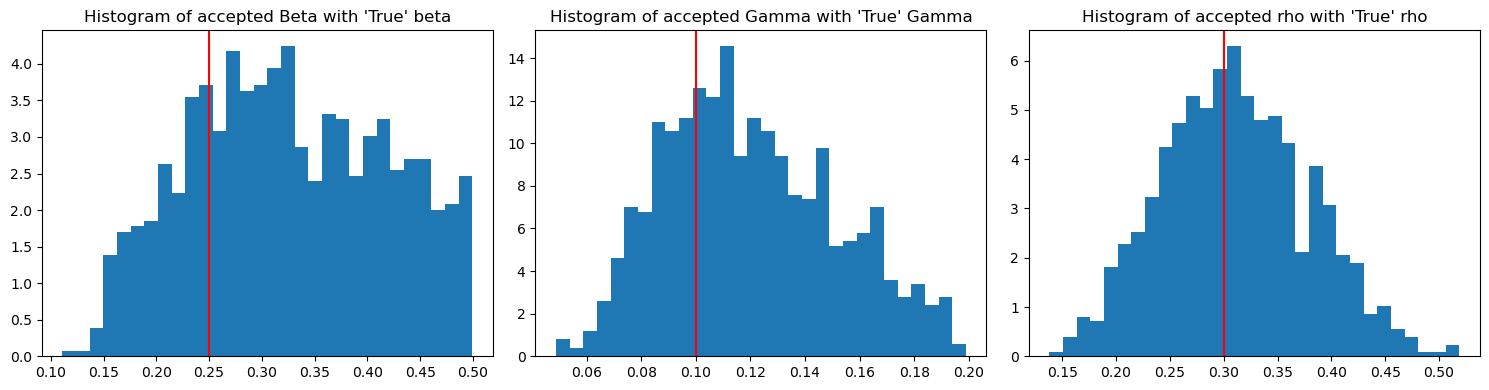

In [255]:
# evaluate 8 summary stats ABC performance on fake parameter
abc_pipeline(compute_8_summary,infected_obs_t, rewiring_obs_t, degree_obs_t)

MSE (beta, gamma, rho): [0.00986084 0.00051603 0.0113093 ]
std (beta, gamma, rho): [0.08205313 0.02052036 0.09349068]
95% CI of Beta: [0.16592661 0.47126729]
95% CI of Gamma: [0.07563371 0.15264402]
95% CI of Rho: [0.17562685 0.53509684]


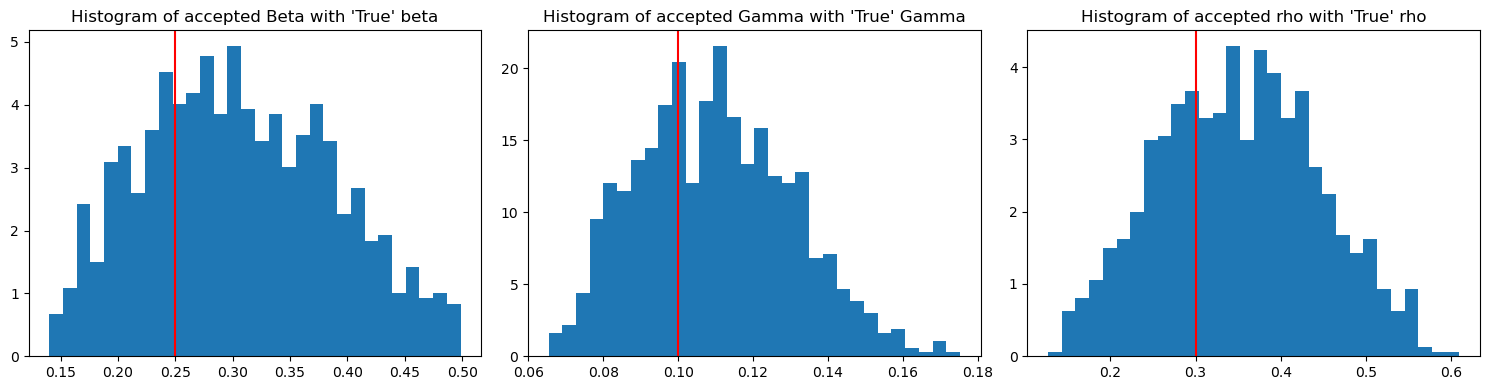

In [256]:
# evaluate 5 summary stats ABC performance on fake parameter
abc_pipeline(compute_5_summary,infected_obs_t, rewiring_obs_t, degree_obs_t)

MSE (beta, gamma, rho): [0.01535969 0.00197054 0.00754579]
std (beta, gamma, rho): [0.09523921 0.03654617 0.08536352]
95% CI of Beta: [0.15832239 0.48852273]
95% CI of Gamma: [0.06220243 0.19242861]
95% CI of Rho: [0.13250816 0.45298274]


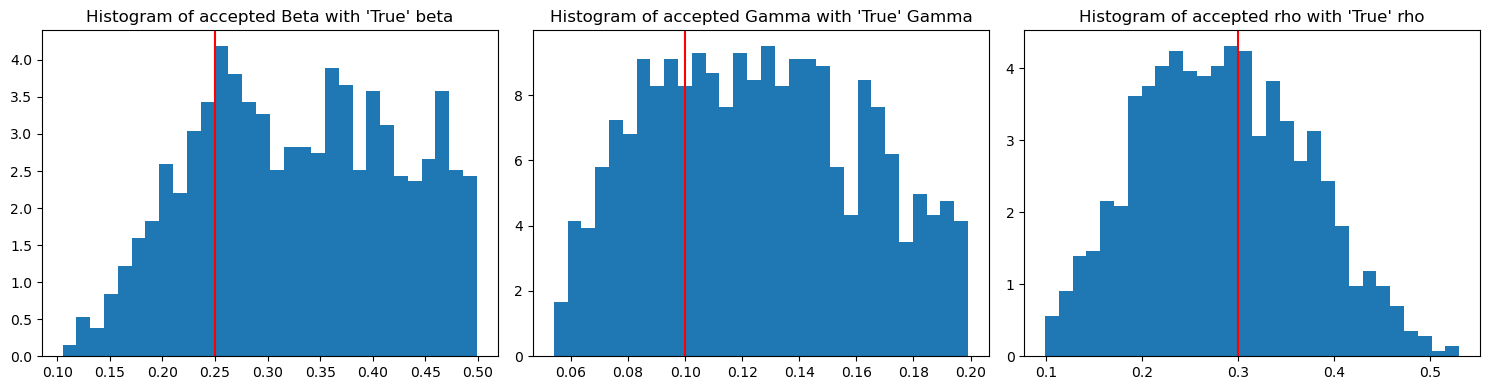

In [257]:
# evaluate l summary stats ABC performance on fake parameter
abc_pipeline(compute_l_summary,infected_obs_t, rewiring_obs_t, degree_obs_t)

In [ ]:
# cross-validation evaluation
def evaluate_results(thetas, summaries):
    model = make_pipeline(
        StandardScaler(),
        LinearRegression()
    )

    scores = cross_val_score(
        model,
        summaries,
        thetas,
        scoring='neg_mean_squared_error',
        cv=5
    )

    return -scores.mean(), scores.std()

mse_9,std9 = evaluate_results(thetas, summaries)
mse_5,std5 = evaluate_results(thetas5, summaries5)
mse_6,std6 = evaluate_results(thetas6, summaries6)
mse_8,std8 = evaluate_results(thetas8, summaries8)
mse_l,stdl = evaluate_results(thetasl, summariesl)

print(f"Cross validation evalutaion of summary_stats_9: MSE = {mse_9:.5f}, std = {std9:.5f}")
print(f"Cross validation evalutaion of summary_stats_5: MSE = {mse_5:.5f}, std = {std5:.5f}")
print(f"Cross validation evalutaion of summary_stats_6: MSE = {mse_6:.5f}, std = {std6:.5f}")
print(f"Cross validation evalutaion of summary_stats_8: MSE = {mse_8:.5f}, std = {std8:.5f}")
print(f"Cross validation evalutaion of summary_stats_l: MSE = {mse_l:.5f}, std = {stdl:.5f}")

Cross validation evalutaion of summary_stats_9: MSE = 0.00352, std = 0.00007
Cross validation evalutaion of summary_stats_5: MSE = 0.00638, std = 0.00025
Cross validation evalutaion of summary_stats_6: MSE = 0.00611, std = 0.00017
Cross validation evalutaion of summary_stats_8: MSE = 0.00360, std = 0.00004
Cross validation evalutaion of summary_stats_l: MSE = 0.00362, std = 0.00006
